----------DAY-5-----------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import warnings 
warnings.filterwarnings("ignore")

PROGRAM-1

In [2]:
#.  Train SVM on breast cancer dataset (linear and RBF kernel) 
from sklearn.datasets import load_breast_cancer

# Load Breast Cancer dataset
data = load_breast_cancer()

# Features and target
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- Linear Kernel ----------------
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print("-----Linear Kernel Results------")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

# ---------------- RBF Kernel ----------------
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
print("\n\n-------RBF Kernel Results-------")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

# ---------------- Accuracy Comparison ----------------
linear_acc = accuracy_score(y_test, y_pred_linear)
rbf_acc = accuracy_score(y_test, y_pred_rbf)
print("\n------Accuracy Comparison---------")
print(f"Linear Kernel Accuracy : {linear_acc:.4f}")
print(f"RBF Kernel Accuracy    : {rbf_acc:.4f}")

#---------------f1 score Comparision -----------------
linear_f1 = f1_score(y_test, y_pred_linear)
rbf_f1 = f1_score(y_test, y_pred_rbf)
print("----------f1-score Comparision ---------")
print(f"Linear Kernel f1_score   :  {round(linear_f1 ,4)} ")
print(f"RBF Kernel f1_score      :  {round(rbf_f1 , 4)}")

-----Linear Kernel Results------
Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[41  2]
 [ 3 68]]


-------RBF Kernel Results-------
Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  2]
 [ 0 71]]

------Accuracy Comparison---------
Linear Kernel Accuracy : 0.9561
RBF Kernel Accuracy    : 0.9825

PROGRAM-2

In [3]:
#Train KNN with k=3, 5, 7 and compare accuracy
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN for different values of k
results = []

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results.append([k, accuracy])

# Display results
results_df = pd.DataFrame(results, columns=["k", "Accuracy"])

print(results_df)

# Best k
best = results_df.loc[results_df["Accuracy"].idxmax()]
print("\nBest k:", int(best["k"]))
print("Best Accuracy:", round(best["Accuracy"], 4))

   k  Accuracy
0  3       1.0
1  5       1.0
2  7       1.0

Best k: 3
Best Accuracy: 1.0


PROGRAM-3

In [4]:
# Perform 5-fold cross-validation on both models 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score

# Load dataset
data = load_breast_cancer()

# Features and target
X = data.data
y = data.target

# ---------------- SVM Models ----------------
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))       ])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))           ])

# ---------------- KNN Models ----------------
knn3 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))       ])

knn5 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))       ])

# ---------------- Cross Validation ----------------
models = {
    "SVM Linear": svm_linear,
    "SVM RBF": svm_rbf,
    "KNN (k=3)": knn3,
    "KNN (k=5)": knn5     }

print("-----5-Fold Cross Validation Results-----")

for name, model in models.items():
    print("-" * 40)
    scores = cross_val_score(model, X, y, cv=5)
    print(name)
    print("Scores:", np.round(scores, 4))
    print("Mean Accuracy:", round(scores.mean(), 4))
    

-----5-Fold Cross Validation Results-----
----------------------------------------
SVM Linear
Scores: [0.9649 0.9825 0.9649 0.9649 0.9823]
Mean Accuracy: 0.9719
----------------------------------------
SVM RBF
Scores: [0.9737 0.9561 1.     0.9649 0.9735]
Mean Accuracy: 0.9736
----------------------------------------
KNN (k=3)
Scores: [0.9737 0.9649 0.9825 0.9474 0.9292]
Mean Accuracy: 0.9595
----------------------------------------
KNN (k=5)
Scores: [0.9649 0.9561 0.9825 0.9561 0.9646]
Mean Accuracy: 0.9649


PROGRAM-4

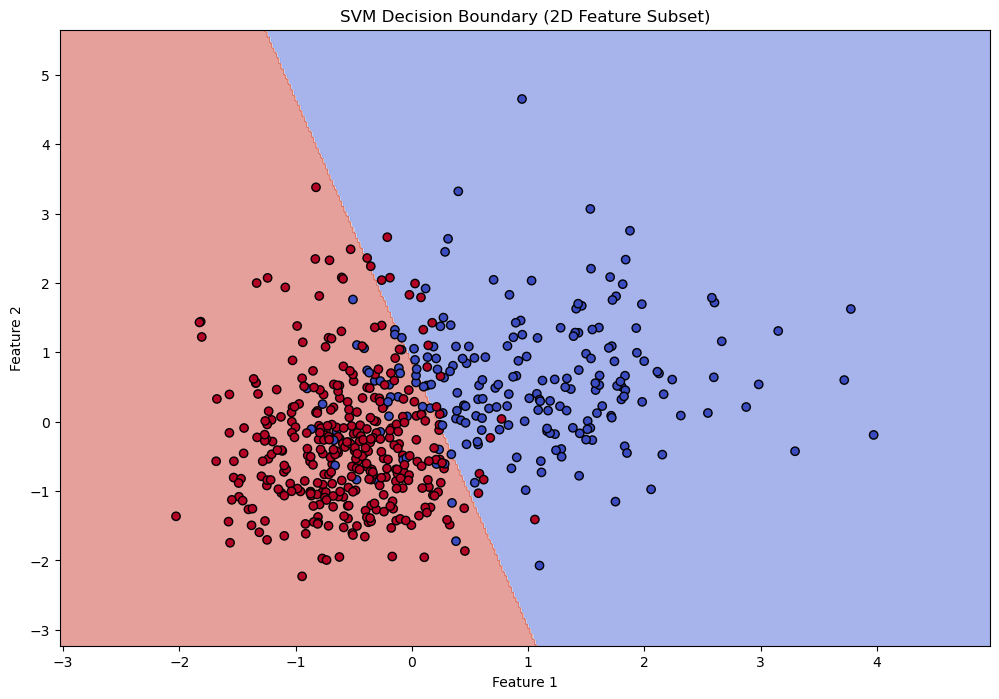

In [5]:
#Plot decision boundary for a 2D feature subset 
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

# Take only 2 features for 2D visualization
X = data.data[:, :2]   # first two features
y = data.target

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM model
model = SVC(kernel='linear')
model.fit(X_scaled, y)

# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)     )

# Predict over grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)

# Scatter actual points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

plt.title("SVM Decision Boundary (2D Feature Subset)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

----------PRACTICE SHEET-------------

PROGRAM-5

In [6]:
#  Handwritten digit classification using KNN on MNIST (subset)
from sklearn.datasets import load_digits

# Load built-in digits dataset (8x8 images)
digits = load_digits()

# Features and target
X = digits.data
y = digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9694444444444444

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



PROGRAM-6

In [7]:
# Compare SVM kernel types (linear, poly, rbf) on the same dataset
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

# Features and target
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different SVM models
models = {
    "Linear Kernel": SVC(kernel="linear", random_state=42),
    "Polynomial Kernel": SVC(kernel="poly", degree=3, random_state=42),
    "RBF Kernel": SVC(kernel="rbf", random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

# Show results
df = pd.DataFrame(results, columns=["Kernel Type", "Accuracy"])
print(df)

# Best model
best = df.loc[df["Accuracy"].idxmax()]
print("\nBest Kernel:", best["Kernel Type"])
print("Best Accuracy:", round(best["Accuracy"], 4))

         Kernel Type  Accuracy
0      Linear Kernel  0.956140
1  Polynomial Kernel  0.868421
2         RBF Kernel  0.982456

Best Kernel: RBF Kernel
Best Accuracy: 0.9825
